- Public score: 0.93828
- Position: 1977 / 2199 ( Top 10% )
- Best Kaggle score: 0.94674

In [1]:
import os.path

from sklearn.ensemble import RandomForestClassifier
from dotenv import load_dotenv
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

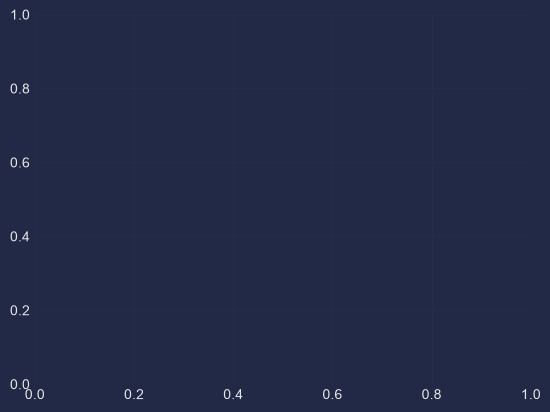

In [2]:
import matplotlib.style as _ms

# Patch for mplcyberpunk expecting matplotlib.style.core
if not hasattr(_ms, "core"):
    _ms.core = _ms

import mplcyberpunk as mpl

load_dotenv()
plt.style.use('cyberpunk')
mpl.add_glow_effects()

In [3]:
# # Download latest version
#
# path = kagglehub.competition_download('playground-series-s6e9',
#                                       output_dir='data/ev_purchase',
#                                       )
#
# print("Path to competition files:", path)

In [4]:
test = pd.read_csv('data/ev_purchase/test.csv', index_col='id')
train = pd.read_csv('data/ev_purchase/train.csv', index_col='id')

In [5]:
train.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [6]:
train.head(10)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
id,,,,,,,,,,,,,,
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
5,50,95938.0,55.1,2,8,15,3.0,Other,Urban,Sedan,No,No,Low,No
6,55,109219.0,42.9,1,1,5,4.0,Male,Suburban,Sedan,Yes,Yes,Low,Yes
7,45,60796.0,52.2,2,13,3,2.0,Other,Urban,SUV,No,Yes,Medium,No
8,39,67725.0,31.5,2,11,3,2.0,Female,Urban,Sedan,No,Yes,Medium,No


In [7]:
cat_columns = train.select_dtypes(include=str).columns
# we need check unique values in categorical columns to see if there are any inconsistencies

train[cat_columns].nunique()

Gender                    3
City_Type                 3
Current_Car_Type          4
Home_Charging_Possible    2
Subsidy_Available         2
Range_Anxiety_Level       3
Will_Buy_EV               2
dtype: int64

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age',
                                   'Annual_Income_USD',
                                   'Daily_Commute_km',
                                   'Number_of_Cars_Owned',
                                   'Charging_Stations_Near_Home',
                                   'Charging_Stations_Near_Work',
                                   'Environmental_Concern_Level'
                                   ]),
        ('label', OrdinalEncoder(), ['Gender',
                                     'Home_Charging_Possible',
                                     'Subsidy_Available',
                                     'Range_Anxiety_Level']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['City_Type',
                                                         'Current_Car_Type']),
    ]
)

In [9]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          n_jobs=-1))
])

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns=['Will_Buy_EV']),
    train['Will_Buy_EV'],
    test_size=0.2,
    random_state=42
)

In [11]:
# save trained pipeline to disk

model_name = 'ev_purchase_pipeline.pkl'

if os.path.exists(model_name):
    print(f'Model file {model_name} already exists. Loading the existing model.')
    pipeline = joblib.load(model_name)
else:
    print(f'Model file {model_name} does not exist. Creating a new model.')
    pipeline.fit(X_train, y_train)
    joblib.dump(pipeline, model_name)
    print("Pipeline saved to 'ev_purchase_pipeline.pkl'")

Model file ev_purchase_pipeline.pkl already exists. Loading the existing model.


C:\Users\Tymur\Projects\MachineLearning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Tymur\Projects\MachineLearning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Tymur\Projects\MachineLearning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from versi

In [12]:
y_pred_pipeline = pipeline.predict(X_val)
accuracy_pipeline = accuracy_score(y_val, y_pred_pipeline)
print(f"Validation Accuracy (Pipeline): {accuracy_pipeline:.4f}")

Validation Accuracy (Pipeline): 0.8938


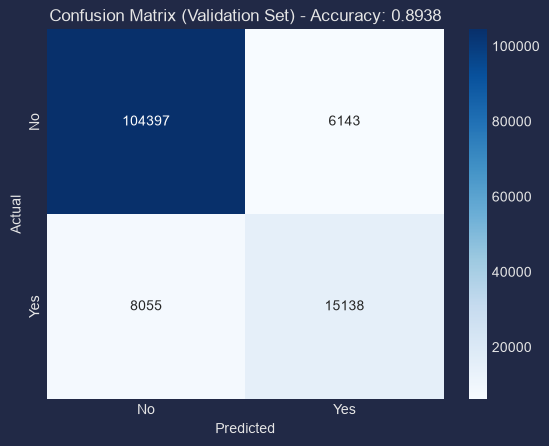

In [13]:
conf_matrix = pd.crosstab(y_val, y_pred_pipeline, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Validation Set) - Accuracy: {accuracy_pipeline:.4f}')
plt.show()

In [14]:
clf_report = classification_report(y_val, y_pred_pipeline)
print(clf_report)

              precision    recall  f1-score   support

          No       0.93      0.94      0.94    110540
         Yes       0.71      0.65      0.68     23193

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733



In [15]:
# Feature importance from the Random Forest model
feature_importances = pipeline.named_steps['classifier'].feature_importances_
# Get feature names from the preprocessor
num_features = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
label_features = ['Gender', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['City_Type', 'Current_Car_Type']).tolist()
all_features = num_features + label_features + cat_features
# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

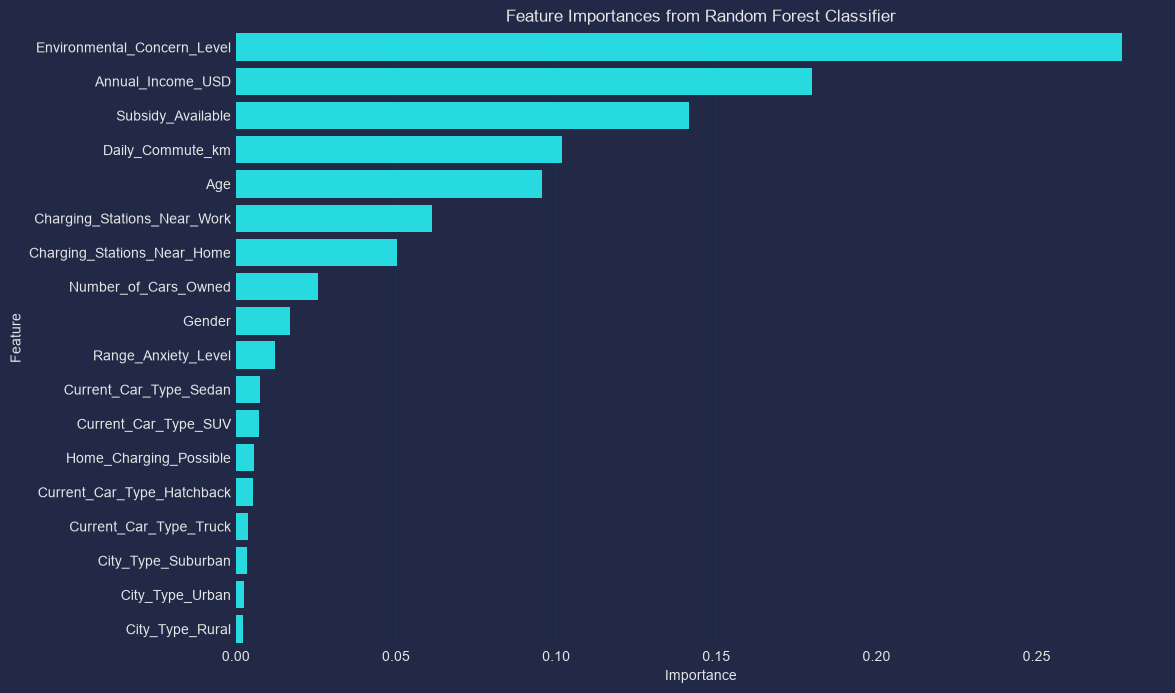

In [16]:
# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.show()

In [29]:
feature_importance_df

,Feature,Importance
6,Environmental_Concern_Level,0.276510
1,Annual_Income_USD,0.179900
9,Subsidy_Available,0.141504
2,Daily_Commute_km,0.101762
0,Age,0.095590
5,Charging_Stations_Near_Work,0.061332
4,Charging_Stations_Near_Home,0.050443
3,Number_of_Cars_Owned,0.025555
7,Gender,0.017017
10,Range_Anxiety_Level,0.012338


In [17]:
# let's prepare the data
# 1. use small piece of the training data ( 1000 rows ) to speed up the hyperparameter optimization process
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=1000,
    random_state=42
)

# 2. Transform the small training data using the preprocessor
X_train_small_transformed = preprocessor.fit_transform(X_train_small)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
# use Optuna to optimize hyperparameters of the Random Forest model
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = RandomForestClassifier(**params, random_state=42)
    cv_scores = cross_val_score(model,
                                X_train_small_transformed,
                                y_train_small,
                                cv=cv,
                                scoring='accuracy')
    accuracy = cv_scores.mean()

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return accuracy

In [20]:
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='maximize',
                            study_name='RandomForest_Optimization',
                            sampler=optuna.samplers.TPESampler(seed=42),
                            pruner=pruner)

study.optimize(objective,
               n_trials=50,
               n_jobs=-1,
               show_progress_bar=True)

print("Best hyperparameters: ", study.best_params)

[I 2026-09-17 15:18:47,230] A new study created in memory with name: no-name-390f8304-7a93-413e-a651-e23de1b37752


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-17 15:18:55,359] Trial 6 finished with value: 0.9000000000000001 and parameters: {'n_estimators': 144, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 6 with value: 0.9000000000000001.
[I 2026-09-17 15:18:55,486] Trial 2 finished with value: 0.898 and parameters: {'n_estimators': 148, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 5, 'criterion': 'entropy'}. Best is trial 6 with value: 0.9000000000000001.
[I 2026-09-17 15:18:57,872] Trial 9 finished with value: 0.892 and parameters: {'n_estimators': 187, 'max_depth': 21, 'min_samples_split': 13, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 6 with value: 0.9000000000000001.
[I 2026-09-17 15:18:58,689] Trial 10 finished with value: 0.8920000000000001 and parameters: {'n_estimators': 208, 'max_depth': 21, 'min_samples_split': 20, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 6 with value: 0.9000000000000001.
[I 2026-09-17 15:18:59,858]

In [21]:
# Visualize the optimization history
optuna.visualization.plot_optimization_history(study)

In [22]:
optuna.visualization.plot_param_importances(study)

In [23]:
optuna.visualization.plot_parallel_coordinate(study)

In [24]:
score = study.best_value
print(f'Best cross-validated accuracy: {score:.4f}')

Best cross-validated accuracy: 0.9020


In [25]:
# Train the final model with the best hyperparameters
best_params = study.best_params
# best_params =  {'n_estimators': 425, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 4, 'criterion': 'entropy'}

final_clf = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_clf)
])

final_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('label', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [26]:
y_pred_final = final_pipeline.predict(X_val)
final_accuracy = accuracy_score(y_val, y_pred_final)
print(f'Final Model Validation Accuracy: {final_accuracy:.4f}')

Final Model Validation Accuracy: 0.8981


In [27]:
y_pred_final = final_pipeline.predict(X_train)
final_accuracy = accuracy_score(y_train, y_pred_final)
print(f'Final Model Training Accuracy: {final_accuracy:.4f}')

Final Model Training Accuracy: 0.9283


In [30]:
# Let's use full training data to train the final model and make predictions on the test set
X, y = train.drop(columns=['Will_Buy_EV']), train['Will_Buy_EV']
final_pipeline.fit(X ,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('label', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [28]:
y_pred_sub = final_pipeline.predict_proba(test)[:, 1]
submission = pd.DataFrame({'id': test.index, 'Will_Buy_EV': y_pred_sub})
submission.to_csv('submission.csv', index=False)

In [31]:
from xgboost import XGBClassifier

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_small = le.fit_transform(y_train_small)
y_val = le.transform(y_val)

ValueError: y contains previously unseen labels: 0

In [35]:
# Train an XGBoost model for comparison
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('label', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of 

In [36]:
y_pred_xgb = xgb_pipeline.predict(X_val)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
print(f"Validation Accuracy (XGBoost): {xgb_accuracy:.4f}")

Validation Accuracy (XGBoost): 0.8988


In [37]:
# Feature importance from the XGBoost model
xgb_feature_importances = xgb_pipeline.named_steps['classifier'].feature_importances_
# Create a DataFrame for feature importances
xgb_feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_feature_importances
}).sort_values(by='Importance', ascending=False)

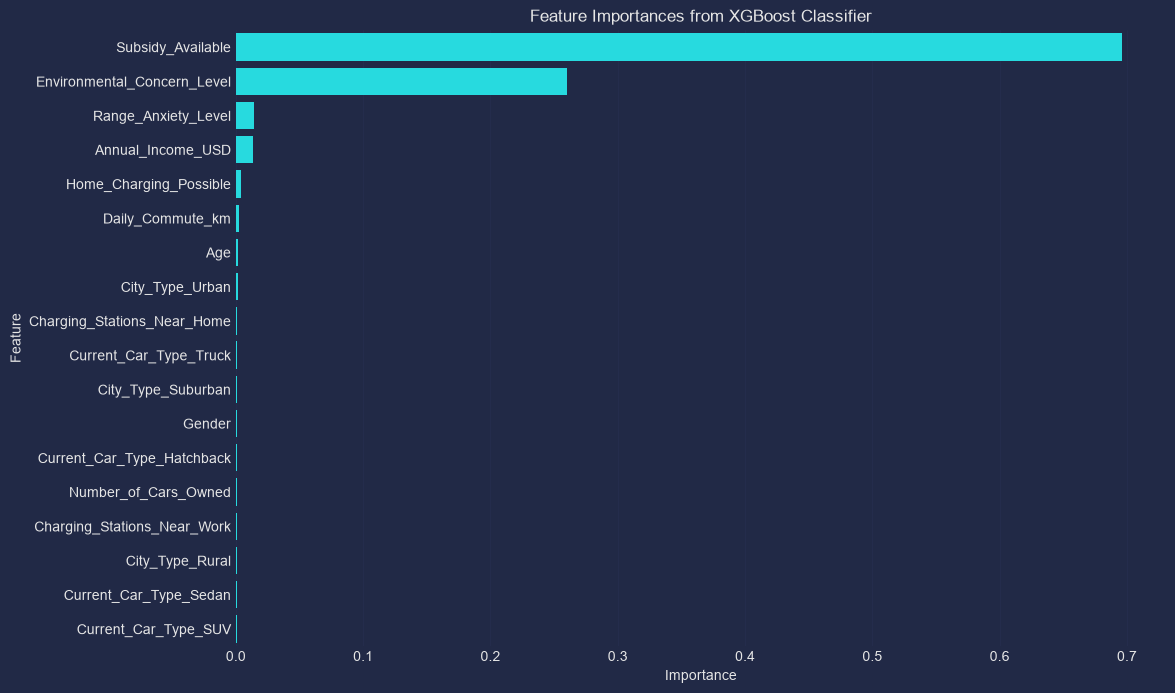

In [38]:
# Plot feature importances for XGBoost
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance_df)
plt.title('Feature Importances from XGBoost Classifier')
plt.show()

In [63]:
# # Tune hyperparameters for XGBoost using Optuna
# def xgb_objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
#         "gamma": trial.suggest_float("gamma", 0.0, 10.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
#         "max_delta_step": trial.suggest_int("max_delta_step", 0, 20),
#         # "tree_method": "hist",
#         # "eval_metric": "logloss",
#     }
#
#     model = XGBClassifier(
#         **params,
#         random_state=42,
#         eval_metric='logloss'
#     )
#     # Train  the model on pre-transformed data limited data
#     cv_scores = cross_val_score(model,
#                                 X_train_small_transformed,
#                                 y_train_small,
#                                 cv=cv,
#                                 scoring='accuracy')
#     accuracy = cv_scores.mean()
#
#     if trial.should_prune():
#         raise optuna.exceptions.TrialPruned()
#
#     return accuracy

In [77]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "gamma": trial.suggest_float("gamma", 0.0, 30.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 30.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 30.0, log=True),
        # "eval_metric": "logloss",
        # "tree_method": "hist",
        "random_state": 42,
    }

    model = XGBClassifier(**params)

    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_small_transformed, y_train_small)):
        X_tr, X_va = X_train_small_transformed[tr_idx], X_train_small_transformed[va_idx]
        y_tr, y_va = y_train_small[tr_idx], y_train_small[va_idx]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False,
            # early_stopping_rounds=20,
        )

        score = model.score(X_va, y_va)
        scores.append(score)
        trial.report(sum(scores) / len(scores), step=fold)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return sum(scores) / len(scores)

In [78]:
pruner = optuna.pruners.MedianPruner()

xgb_study = optuna.create_study(direction='maximize',
                                 study_name='XGBoost_Optimization',
                                 sampler=optuna.samplers.TPESampler(seed=42),
                                 pruner=pruner)

xgb_study.optimize(xgb_objective,
                   n_trials=150,
                   n_jobs=-1,
                   show_progress_bar=True)

[I 2026-09-17 16:11:04,881] A new study created in memory with name: XGBoost_Optimization


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-09-17 16:11:06,236] Trial 0 finished with value: 0.884 and parameters: {'n_estimators': 188, 'max_depth': 6, 'learning_rate': 0.14428260491309186, 'subsample': 0.9537871427328125, 'colsample_bytree': 0.6070094735292404, 'min_child_weight': 20, 'gamma': 9.629583012848624, 'reg_alpha': 4.305160504256028e-08, 'reg_lambda': 0.0015765151888054091}. Best is trial 0 with value: 0.884.
[I 2026-09-17 16:11:06,657] Trial 10 finished with value: 0.89 and parameters: {'n_estimators': 245, 'max_depth': 11, 'learning_rate': 0.13622382287179713, 'subsample': 0.8128163405397499, 'colsample_bytree': 0.9235258462008338, 'min_child_weight': 14, 'gamma': 12.409250262647678, 'reg_alpha': 0.24390641988939812, 'reg_lambda': 0.5061103510933035}. Best is trial 10 with value: 0.89.
[I 2026-09-17 16:11:06,866] Trial 11 finished with value: 0.8030000000000002 and parameters: {'n_estimators': 199, 'max_depth': 9, 'learning_rate': 0.008782848366652366, 'subsample': 0.9183138100316903, 'colsample_bytree': 0.

In [79]:
best_score = xgb_study.best_value
best_params = xgb_study.best_params
print(f'Best cross-validated accuracy for XGBoost: {best_score:.4f}')
print("Best hyperparameters for XGBoost: ", best_params)

Best cross-validated accuracy for XGBoost: 0.9090
Best hyperparameters for XGBoost:  {'n_estimators': 222, 'max_depth': 4, 'learning_rate': 0.12426996200754338, 'subsample': 0.9087020106169653, 'colsample_bytree': 0.6292941148873847, 'min_child_weight': 14, 'gamma': 1.323869940929618, 'reg_alpha': 8.524386618759805e-06, 'reg_lambda': 0.002243466647224461}


In [80]:
# Visualize the optimization history for XGBoost
optuna.visualization.plot_optimization_history(xgb_study)

In [81]:
# Visualize parameter importances for XGBoost
optuna.visualization.plot_param_importances(xgb_study)

In [82]:
# Visualize parallel coordinate plot for XGBoost
optuna.visualization.plot_parallel_coordinate(xgb_study)

In [ ]:
# Best hyperparameters for XGBoost:  {'n_estimators': 309, 'max_depth': 9, 'learning_rate': 0.2613765708422029, 'subsample': 0.9802642633747923, 'colsample_bytree': 0.5827220970702967, 'gamma': 2.264710867164483}